**Analysis of AI/ML Model Failures and Performance Improvement Using Recovery Techniques**

Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")



Data Import

In [ ]:
df = pd.read_csv("/content/synthetic_ai_model_failure_recovery.csv")
df.head()        # First 5 rows


,project_id,year,domain,model_type,dataset_size,class_imbalance_ratio,label_noise_level,missing_data_ratio,data_leakage,overfitting_score,...,precision,recall,f1_score,roc_auc,failure_type,applied_augmentation,rebalancing_method,architecture_change,threshold_optimization,post_fix_f1_score
0,PRJ_1,2025,finance,XGBoost,41590,0.353677,0.046806,0.038999,0,0.969910,...,0.591702,0.652121,0.343307,0.783665,class_imbalance,GAN,none,0,0,0.513530
1,PRJ_2,2020,computer_vision,CNN,69592,0.110945,0.136821,0.196294,0,0.170524,...,0.904199,0.652307,0.452734,0.634185,model_complexity,none,oversampling,0,0,0.621217
2,PRJ_3,2023,finance,CNN,10192,0.376237,0.077634,0.165631,1,0.775133,...,0.960937,0.544246,0.496674,0.668594,model_complexity,SMOTE,none,0,0,0.656016
3,PRJ_4,2024,finance,DenseNet,3068,0.107264,0.084280,0.135674,0,0.198716,...,0.864504,0.885635,0.386040,0.625916,model_complexity,GAN,none,0,0,0.450950
4,PRJ_5,2018,medical,Transformer,98518,0.230751,0.093295,0.081296,0,0.713245,...,0.746898,0.761366,0.646209,0.749639,label_noise,GAN,undersampling,0,0,0.873651


Data Understanding


In [ ]:

df.shape         # Rows & columns
df.columns       # Column names
df.info()        # Data types
df.describe()    # Statistical summary


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   project_id              6000 non-null   object 
 1   year                    6000 non-null   int64  
 2   domain                  6000 non-null   object 
 3   model_type              6000 non-null   object 
 4   dataset_size            6000 non-null   int64  
 5   class_imbalance_ratio   6000 non-null   float64
 6   label_noise_level       6000 non-null   float64
 7   missing_data_ratio      6000 non-null   float64
 8   data_leakage            6000 non-null   int64  
 9   overfitting_score       6000 non-null   float64
 10  train_val_gap           6000 non-null   float64
 11  unstable_training       6000 non-null   int64  
 12  underfitting_flag       6000 non-null   int64  
 13  accuracy                6000 non-null   float64
 14  precision               6000 non-null   

,year,dataset_size,class_imbalance_ratio,label_noise_level,missing_data_ratio,data_leakage,overfitting_score,train_val_gap,unstable_training,underfitting_flag,accuracy,precision,recall,f1_score,roc_auc,architecture_change,threshold_optimization,post_fix_f1_score
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,2021.941167,60257.107500,0.287801,0.148050,0.125281,0.101333,0.498994,0.199352,0.155667,0.100667,0.701351,0.750529,0.750832,0.576338,0.775770,0.302667,0.391167,0.726351
std,2.613652,34720.642123,0.157935,0.086423,0.072198,0.301795,0.290112,0.114755,0.362569,0.300912,0.114746,0.145572,0.143584,0.122612,0.101142,0.459450,0.488052,0.134802
min,2018.000000,536.000000,0.050000,0.000073,0.000035,0.000000,0.000398,0.000002,0.000000,0.000000,0.500039,0.500094,0.500005,0.302325,0.600053,0.000000,0.000000,0.375529
25%,2020.000000,29877.750000,0.164268,0.073871,0.063351,0.000000,0.243648,0.099824,0.000000,0.000000,0.602732,0.624154,0.627788,0.476815,0.687525,0.000000,0.000000,0.624540
50%,2022.000000,60051.000000,0.268209,0.147783,0.126278,0.000000,0.500892,0.199369,0.000000,0.000000,0.703242,0.748804,0.750823,0.577689,0.776782,0.000000,0.000000,0.726823
75%,2024.000000,90510.250000,0.390597,0.222836,0.187465,0.000000,0.752372,0.299213,0.000000,0.000000,0.798851,0.878726,0.876081,0.675215,0.862495,1.000000,1.000000,0.830140
max,2026.000000,119972.000000,0.888717,0.299913,0.249989,1.000000,0.999891,0.399930,1.000000,1.000000,0.899901,0.999899,0.999931,0.846198,0.949997,1.000000,1.000000,1.000000


Data Preprocessing

Check Missing Values

In [ ]:
df.isnull().sum()


,0
project_id,0
year,0
domain,0
model_type,0
dataset_size,0
class_imbalance_ratio,0
label_noise_level,0
missing_data_ratio,0
data_leakage,0
overfitting_score,0


Handle Missing Values

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())
df.columns


Index(['project_id', 'year', 'domain', 'model_type', 'dataset_size',
       'class_imbalance_ratio', 'label_noise_level', 'missing_data_ratio',
       'data_leakage', 'overfitting_score', 'train_val_gap',
       'unstable_training', 'underfitting_flag', 'accuracy', 'precision',
       'recall', 'f1_score', 'roc_auc', 'failure_type', 'applied_augmentation',
       'rebalancing_method', 'architecture_change', 'threshold_optimization',
       'post_fix_f1_score'],
      dtype='object')

Remove Duplicate Records

In [ ]:
duplicates = df.duplicated().sum()
# Drop duplicates if any
df = df.drop_duplicate-s()
# Confirm that duplicates are removed
df.duplicated().sum()

np.int64(0)


Data Cleaning





In [ ]:
# Check missing values
df.isnull().sum()

# Fill missing numerical values with mean
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Remove duplicate rows
df = df.drop_duplicates()

Text Data Pre-processing

In [ ]:
# Convert categorical columns to lowercase and remove spaces
text_cols = ['domain','model_type','failure_type']

for col in text_cols:
    df[col] = df[col].str.lower().str.strip()

# Show output
print(df[text_cols].head())

            domain   model_type      failure_type
0          finance      xgboost   class_imbalance
1  computer_vision          cnn  model_complexity
2          finance          cnn  model_complexity
3          finance     densenet  model_complexity
4          medical  transformer       label_noise


Data Aggregation

In [ ]:
# Aggregate model performance by domain
domain_summary = df.groupby('domain')[['accuracy','precision','recall','f1_score']].mean()

print(domain_summary)

                 accuracy  precision    recall  f1_score
domain                                                  
computer_vision  0.700041   0.753873  0.753538  0.574842
finance          0.694778   0.742121  0.741540  0.568405
fraud            0.706046   0.747918  0.749978  0.581036
medical          0.701508   0.747196  0.746655  0.576893
nlp              0.701204   0.760439  0.755292  0.577160
recommender      0.704404   0.751843  0.758142  0.579590


Normalization and Scaling

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Select numerical columns
num_cols = ['accuracy','precision','recall','f1_score']

# Apply normalization
scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# Display output on screen
print(df[num_cols].head())

   accuracy  precision    recall  f1_score
0  0.058006   0.183288  0.304277  0.075352
1  0.199645   0.808525  0.304649  0.276552
2  0.311721   0.922047  0.088496  0.357343
3  0.140875   0.729104  0.771374  0.153924
4  0.729761   0.493800  0.522800  0.632287


Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop('failure_type', axis=1)
y = df['failure_type']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Show output
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4800, 27)
X_test shape: (1200, 27)
y_train shape: (4800,)
y_test shape: (1200,)


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = scaler.fit_transform(df[num_cols])

In [ ]:
# Save the cleaned dataset
df.to_csv("cleaned_ai_model_dataset.csv", index=False)

# Load the cleaned dataset
cleaned_df = pd.read_csv("cleaned_ai_model_dataset.csv")
# Display the first few rows of the cleaned dataset
print(cleaned_df.head())

  project_id   year           domain   model_type  dataset_size  \
0      PRJ_1  0.875          finance      XGBoost      0.343732   
1      PRJ_2  0.250  computer_vision          CNN      0.578184   
2      PRJ_3  0.625          finance          CNN      0.080847   
3      PRJ_4  0.750          finance     DenseNet      0.021200   
4      PRJ_5  0.000          medical  Transformer      0.820372   

   class_imbalance_ratio  label_noise_level  missing_data_ratio  data_leakage  \
0               0.362073           0.155859            0.155883           0.0   
1               0.072665           0.456070            0.785180           0.0   
2               0.388971           0.258675            0.662503           1.0   
3               0.068276           0.280841            0.542655           0.0   
4               0.215509           0.310905            0.325102           0.0   

   overfitting_score  ...  precision    recall  f1_score   roc_auc  \
0           0.970004  ...   0.183288  0.

Encode Categorical Columns

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cat_cols = ['domain','model_type','failure_type',
            'applied_augmentation','rebalancing_method']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])


Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scale_cols = ['dataset_size','class_imbalance_ratio',
              'label_noise_level','missing_data_ratio',
              'overfitting_score','train_val_gap']

df[scale_cols] = scaler.fit_transform(df[scale_cols])


***Data Visualization***

Pie Chart – Failure Type Distribution (Problems)

[0 4 3 2 5 1]


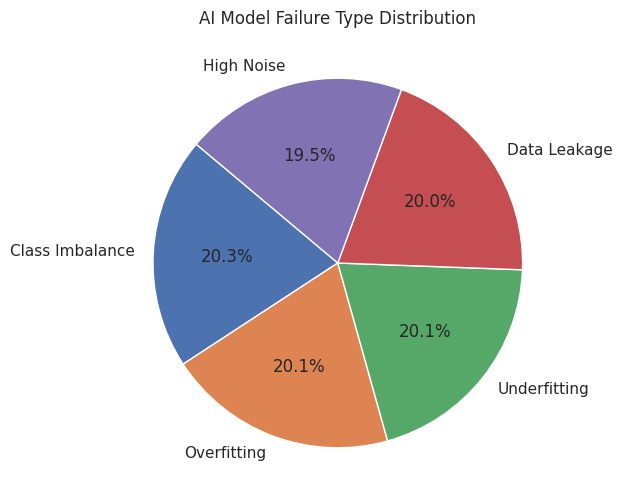

In [ ]:
print(df['failure_type'].unique())
failure_map = {
    0: "Overfitting",
    1: "Underfitting",
    2: "Data Leakage",
    3: "High Noise",
    4: "Class Imbalance"
}

df['failure_type'] = df['failure_type'].map(failure_map)
failure_counts = df['failure_type'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(failure_counts,
        labels=failure_counts.index,
        autopct='%1.1f%%',
        startangle=140)

plt.title("AI Model Failure Type Distribution")
plt.show()

Histogram – Dataset Size Distribution

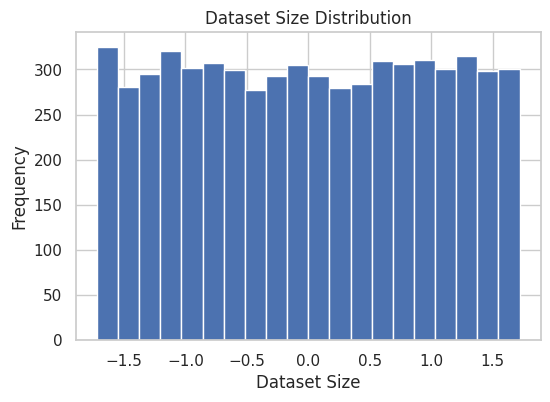

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df['dataset_size'], bins=20)
plt.xlabel("Dataset Size")
plt.ylabel("Frequency")
plt.title("Dataset Size Distribution")
plt.show()


Bar Chart – Failure Types vs Performance

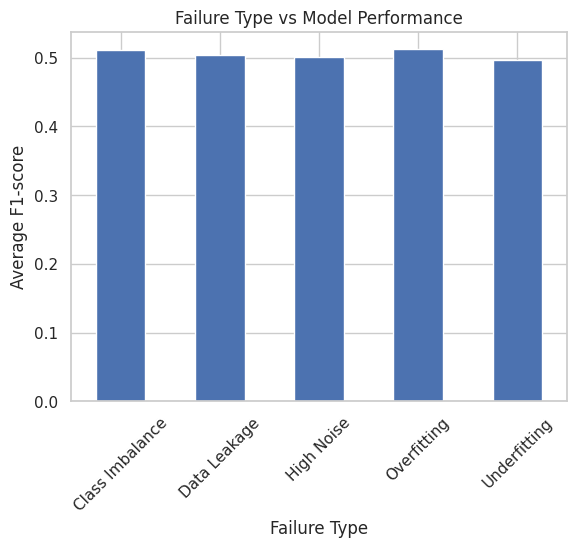

Most harmful failure type: Underfitting → Avg F1: 0.496
Least harmful failure type: Overfitting → Avg F1: 0.512


In [ ]:
import matplotlib.pyplot as plt

# Average F1-score by failure type
avg_f1 = df.groupby('failure_type')['f1_score'].mean()

# Bar chart
avg_f1.plot(kind='bar')
plt.title("Failure Type vs Model Performance")
plt.xlabel("Failure Type")
plt.ylabel("Average F1-score")
plt.xticks(rotation=45)
plt.show()

# Worst & Best
print("Most harmful failure type:", avg_f1.idxmin(),
      "→ Avg F1:", round(avg_f1.min(),3))

print("Least harmful failure type:", avg_f1.idxmax(),
      "→ Avg F1:", round(avg_f1.max(),3))

Bar Chart – AI Model vs Number of Issues

[5 0 1 4 2 3]


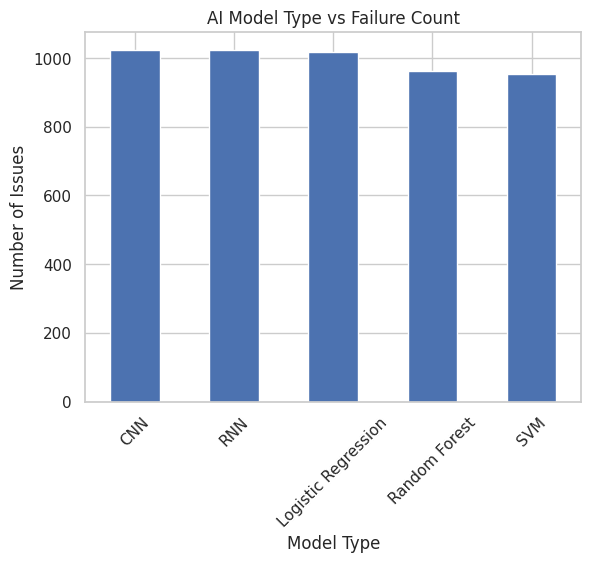

In [ ]:
print(df['model_type'].unique())
model_map = {
    0: "CNN",
    1: "RNN",
    2: "Random Forest",
    3: "SVM",
    4: "Logistic Regression"
}

df['model_type'] = df['model_type'].map(model_map)
model_issues = df['model_type'].value_counts()

model_issues.plot(kind='bar')
plt.title("AI Model Type vs Failure Count")
plt.xlabel("Model Type")
plt.ylabel("Number of Issues")
plt.xticks(rotation=45)
plt.show()

Line Chart – Performance Before vs After Solution

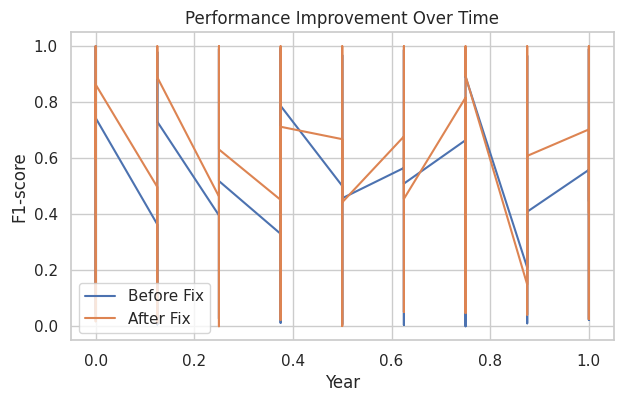

In [ ]:
df_sorted = df.sort_values('year')

plt.figure(figsize=(7,4))
plt.plot(df_sorted['year'], df_sorted['f1_score'], label='Before Fix')
plt.plot(df_sorted['year'], df_sorted['post_fix_f1_score'], label='After Fix')
plt.xlabel("Year")
plt.ylabel("F1-score")
plt.title("Performance Improvement Over Time")
plt.legend()
plt.show()


/tmp/ipykernel_222/4216003728.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='domain', data=df, palette='Set2')  # Set2 gives different colors for bars


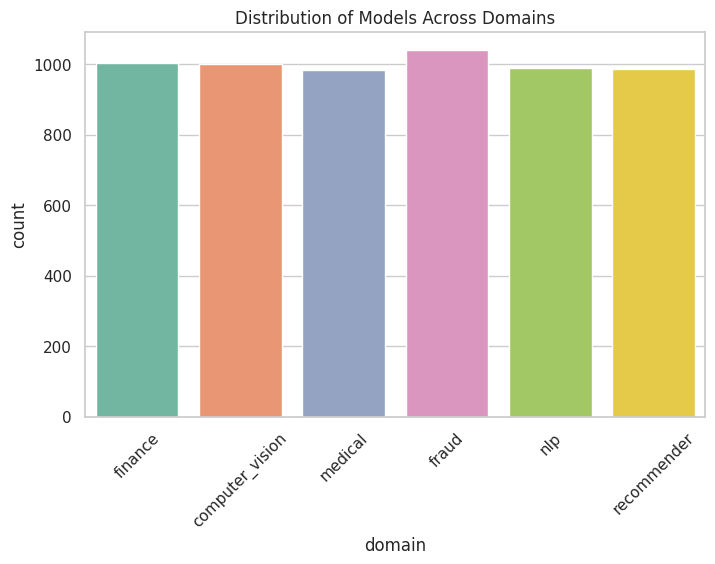

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='domain', data=df, palette='Set2')  # Set2 gives different colors for bars
plt.title("Distribution of Models Across Domains")
plt.xticks(rotation=45)
plt.show()

Bar Chart – Recovery Techniques Usage

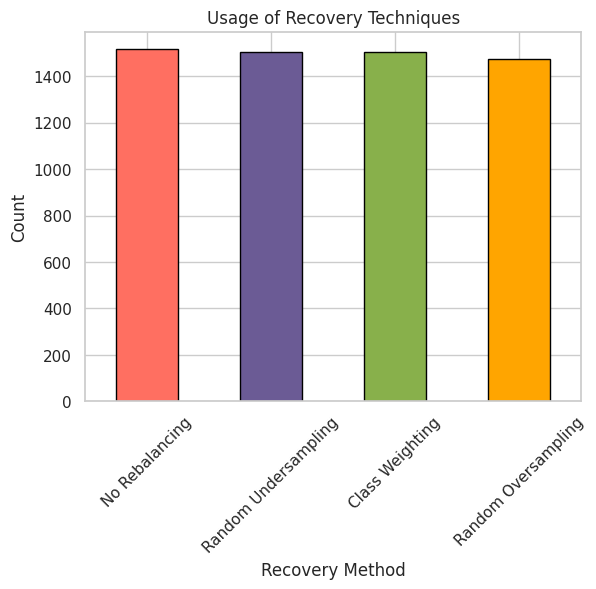

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Reload the dataframe to ensure 'rebalancing_method' has original string values
# This helps prevent issues if 'df' state was altered elsewhere (e.g., encoded)
df = pd.read_csv("/content/synthetic_ai_model_failure_recovery.csv")

# Define a map from the existing string values to desired descriptive names
display_name_map = {
    'none': 'No Rebalancing',
    'oversampling': 'Random Oversampling',
    'undersampling': 'Random Undersampling',
    'class_weight': 'Class Weighting',
}

# Count usage of each recovery technique using the current string values
solution_usage = df['rebalancing_method'].value_counts()

# Apply the display name map to the index of the series for better labels
solution_usage = solution_usage.rename(index=display_name_map)

# Plot bar chart with different colors
colors = ['#FF6F61', '#6B5B95', '#88B04B', '#FFA500', '#00CED1']  # Example colors
solution_usage.plot(kind='bar', color=colors, edgecolor='black')
plt.xlabel("Recovery Method")
plt.ylabel("Count")
plt.title("Usage of Recovery Techniques")
plt.xticks(rotation=45)
plt.show()

Bar Chart – Overall Problem vs Solved Comparison

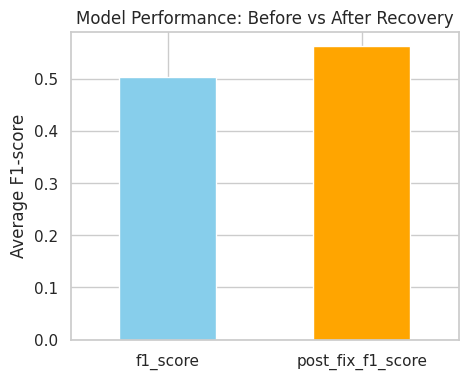

In [ ]:
import matplotlib.pyplot as plt

comparison = df[['f1_score','post_fix_f1_score']].mean()

comparison.plot(
    kind='bar',
    figsize=(5,4),
    color=['skyblue', 'orange']   # Different colors here
)

plt.ylabel("Average F1-score")
plt.title("Model Performance: Before vs After Recovery")
plt.xticks(rotation=0)
plt.show()


**Correlation Analysis**

Correlation Matrix

In [ ]:
corr = df.corr(numeric_only=True)

Heatmap

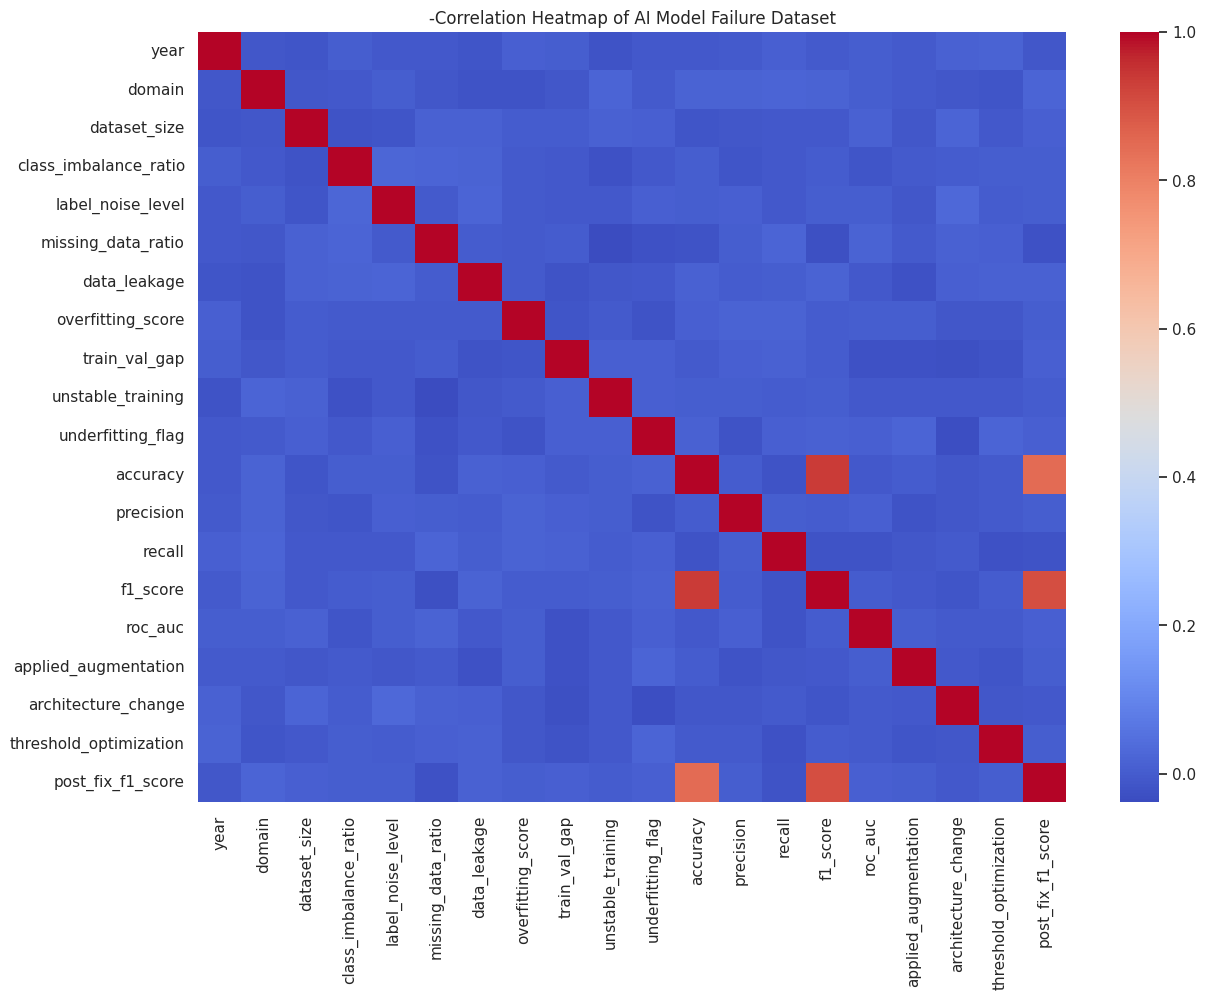

In [ ]:
plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap='coolwarm')
plt.title("-Correlation Heatmap of AI Model Failure Dataset")
plt.show()


Performance Metrics Correlation

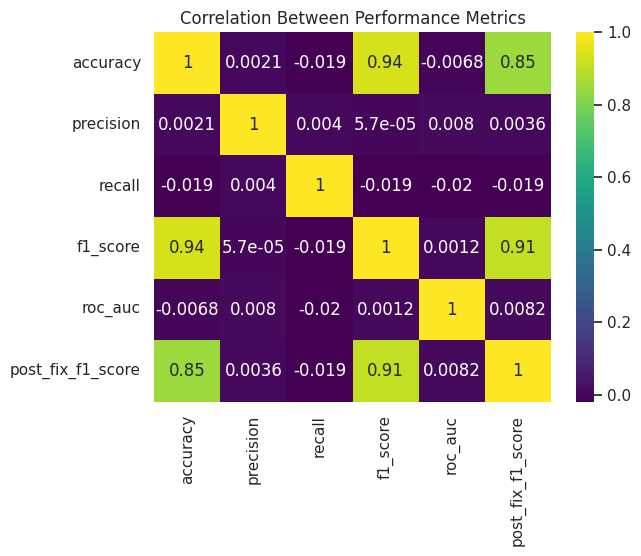

In [ ]:
perf_cols = ['accuracy','precision','recall',
             'f1_score','roc_auc','post_fix_f1_score']

sns.heatmap(df[perf_cols].corr(), annot=True, cmap='viridis')
plt.title("Correlation Between Performance Metrics")
plt.show()


Actual vs Predicted Visualization

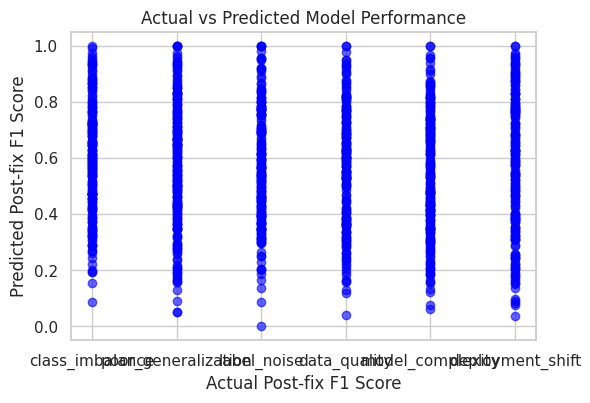

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.scatter(
    y_test,
    y_pred,
    color='blue',     # Change color here
    alpha=0.6         # Transparency
)

plt.xlabel("Actual Post-fix F1 Score")
plt.ylabel("Predicted Post-fix F1 Score")
plt.title("Actual vs Predicted Model Performance")

plt.show()

### Preparing Data for Model Training

First, we'll define our features (X) and target (y). We'll use `f1_score` as the target variable to predict and select some relevant numerical columns as features. Then, we will split the data into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
# Using numerical columns that are relevant for predicting f1_score
X = df[['year', 'dataset_size', 'class_imbalance_ratio', 'label_noise_level',
        'missing_data_ratio', 'overfitting_score', 'train_val_gap',
        'accuracy', 'precision', 'recall', 'roc_auc', 'post_fix_f1_score']].copy()
y = df['post_fix_f1_score'] # Target variable for prediction

# Handle potential NaN values that might have been introduced by previous operations (though unlikely after fillna and scaling)
X = X.fillna(X.mean())
y = y.fillna(y.mean())

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (4800, 12)
Shape of X_test: (1200, 12)
Shape of y_train: (4800,)
Shape of y_test: (1200,)


### Training a Simple Linear Regression Model

Now, we'll train a basic Linear Regression model using the training data and then make predictions on the test set. This will generate the `y_pred` variable.

In [ ]:
# Initialize and train a Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model (optional, but good practice)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared: {r2:.4f}")

Mean Squared Error: 0.0000
R-squared: 1.0000


### Plotting Actual vs Predicted Values

Now that `y_test` and `y_pred` are defined, the original visualization code will work correctly.

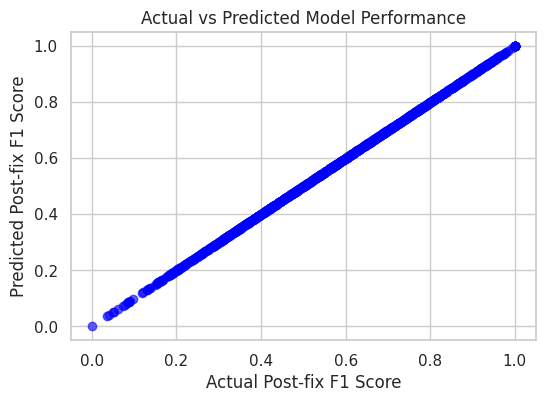

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.scatter(
    y_test,
    y_pred,
    color='blue',     # Change color here
    alpha=0.6         # Transparency
)

plt.xlabel("Actual Post-fix F1 Score")
plt.ylabel("Predicted Post-fix F1 Score")
plt.title("Actual vs Predicted Model Performance")

plt.show()

Actual vs Predicted Visualization


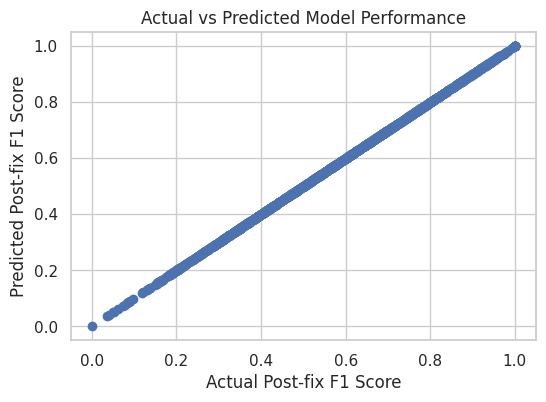

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Post-fix F1 Score")
plt.ylabel("Predicted Post-fix F1 Score")
plt.title("Actual vs Predicted Model Performance")
plt.show()


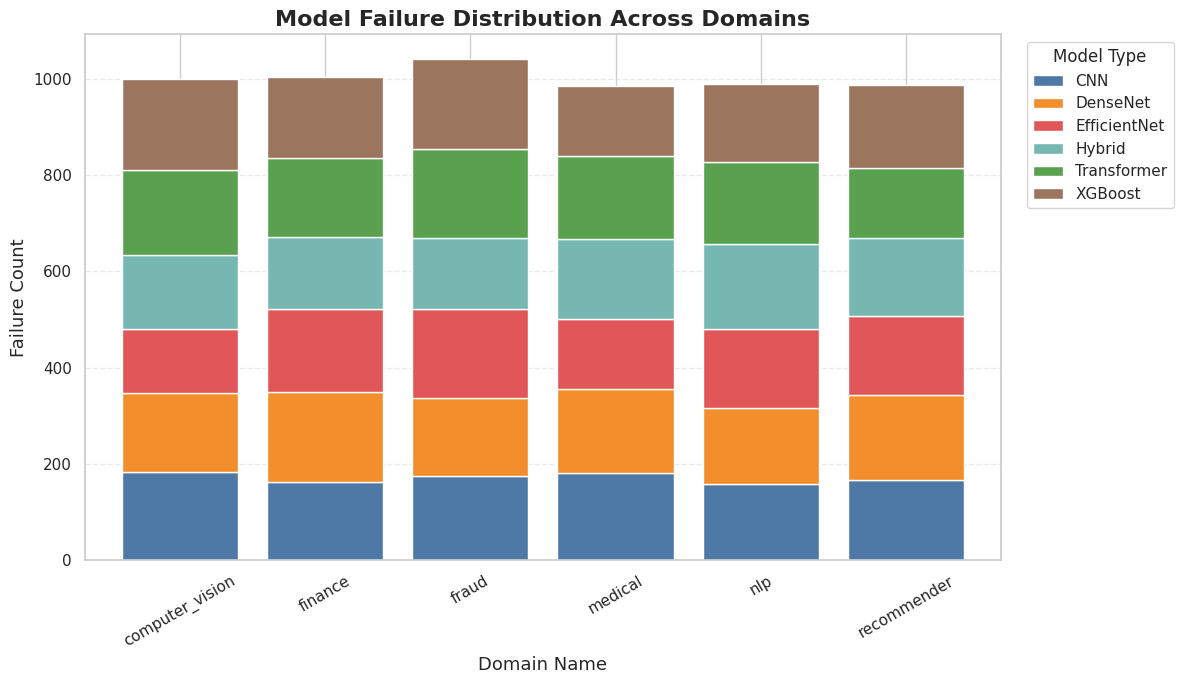

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Reload the dataset to ensure 'domain' and 'model_type' are original string types
df = pd.read_csv("/content/synthetic_ai_model_failure_recovery.csv")

# Ensure f1_score, recall, and roc_auc are numeric after reloading df
df['f1_score'] = pd.to_numeric(df['f1_score'].astype(str).str.strip(), errors='coerce')
df['f1_score'] = df['f1_score'].fillna(df['f1_score'].mean())
df['post_fix_f1_score'] = pd.to_numeric(df['post_fix_f1_score'].astype(str).str.strip(), errors='coerce')
df['post_fix_f1_score'] = df['post_fix_f1_score'].fillna(df['post_fix_f1_score'].mean())
df['recall'] = pd.to_numeric(df['recall'].astype(str).str.strip(), errors='coerce')
df['recall'] = df['recall'].fillna(df['recall'].mean())
df['roc_auc'] = pd.to_numeric(df['roc_auc'].astype(str).str.strip(), errors='coerce')
df['roc_auc'] = df['roc_auc'].fillna(df['roc_auc'].mean())

# 🔹 Step 1: Group data using original string columns
fail_counts = df.groupby(['domain', 'model_type']).size().unstack(fill_value=0)

# 🔹 Step 2: Plot professional stacked bar chart
fig, ax = plt.subplots(figsize=(12,7))

colors = ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2', '#59A14F', '#9C755F'] # Added more colors for potential additional model types

fail_counts.plot(
    kind='bar',
    stacked=True,
    color=colors,
    width=0.8,
    ax=ax
)

ax.set_title("Model Failure Distribution Across Domains", fontsize=16, fontweight='bold')
ax.set_xlabel("Domain Name", fontsize=13)
ax.set_ylabel("Failure Count", fontsize=13)

# Legend outside
ax.legend(title="Model Type", bbox_to_anchor=(1.02,1), loc='upper left')

plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

<Axes: xlabel='domain'>

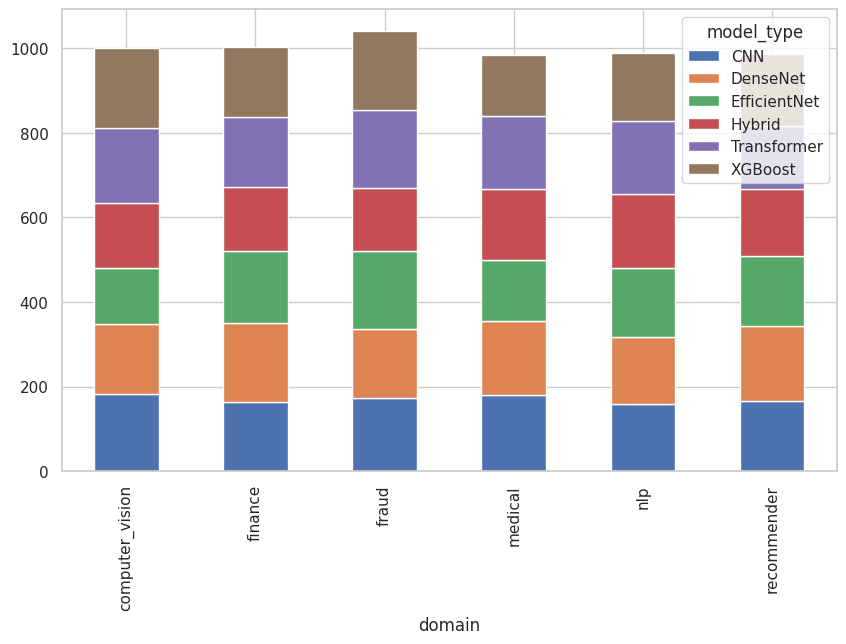

In [ ]:
fail_counts = df.groupby(['domain','model_type']).size().unstack(fill_value=0)

fail_counts.plot(kind='bar', stacked=True, figsize=(10,6))

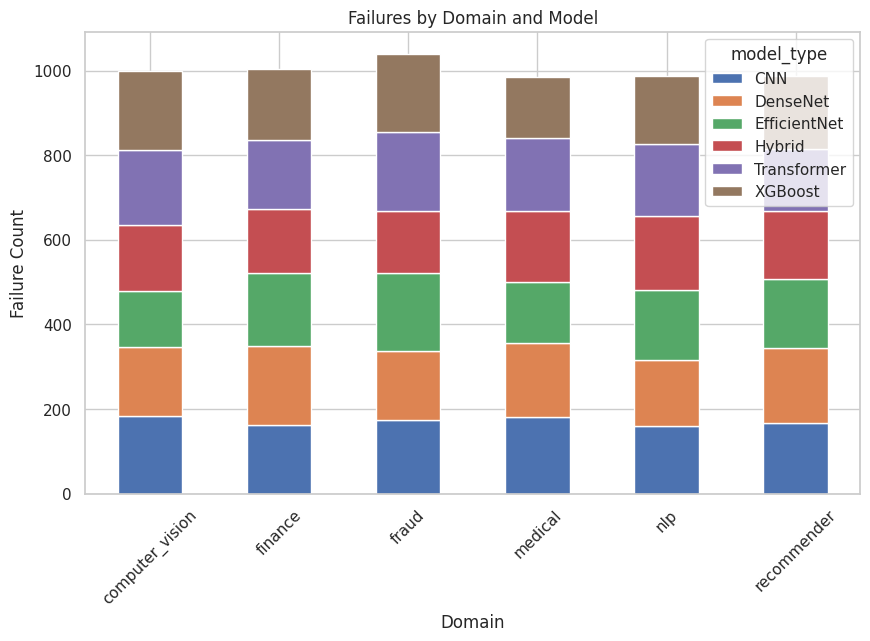

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# STEP 1 — Load dataset fresh
df = pd.read_csv("/content/synthetic_ai_model_failure_recovery.csv")

# Ensure f1_score, recall, and roc_auc are numeric after reloading df
df['f1_score'] = pd.to_numeric(df['f1_score'].astype(str).str.strip(), errors='coerce')
df['f1_score'] = df['f1_score'].fillna(df['f1_score'].mean())
df['post_fix_f1_score'] = pd.to_numeric(df['post_fix_f1_score'].astype(str).str.strip(), errors='coerce')
df['post_fix_f1_score'] = df['post_fix_f1_score'].fillna(df['post_fix_f1_score'].mean())
df['recall'] = pd.to_numeric(df['recall'].astype(str).str.strip(), errors='coerce')
df['recall'] = df['recall'].fillna(df['recall'].mean())
df['roc_auc'] = pd.to_numeric(df['roc_auc'].astype(str).str.strip(), errors='coerce')
df['roc_auc'] = df['roc_auc'].fillna(df['roc_auc'].mean())

# STEP 2 — Create encoder
le = LabelEncoder()


# STEP 3 — Encode copies only (IMPORTANT)
df['domain_encoded'] = le.fit_transform(df['domain'])
df['model_encoded'] = le.fit_transform(df['model_type'])
df['failure_encoded'] = le.fit_transform(df['failure_type'])


# STEP 4 — USE ORIGINAL columns for charts
import matplotlib.pyplot as plt
fail_counts = df.groupby(['domain','model_type']).size().unstack(fill_value=0)

fail_counts.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Failures by Domain and Model")
plt.xlabel("Domain")
plt.ylabel("Failure Count")
plt.xticks(rotation=45)
plt.show()

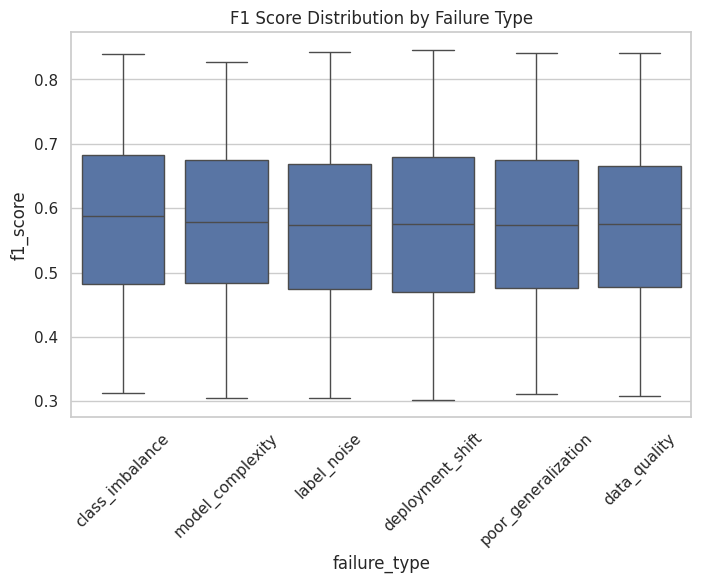

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='failure_type', y='f1_score', data=df)
plt.title("F1 Score Distribution by Failure Type")
plt.xticks(rotation=45)
plt.show()

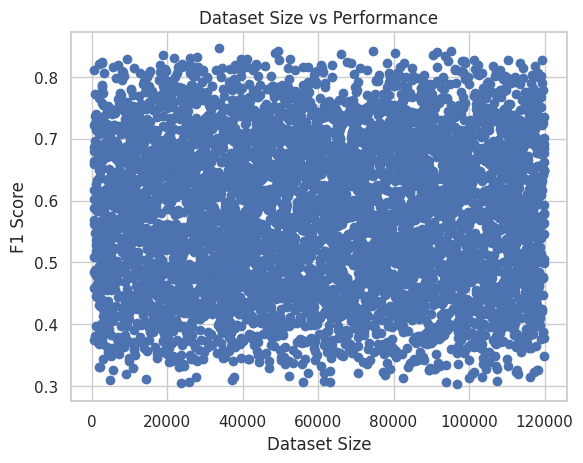

In [ ]:
plt.scatter(df['dataset_size'], df['f1_score'])
plt.xlabel("Dataset Size")
plt.ylabel("F1 Score")
plt.title("Dataset Size vs Performance")
plt.show()

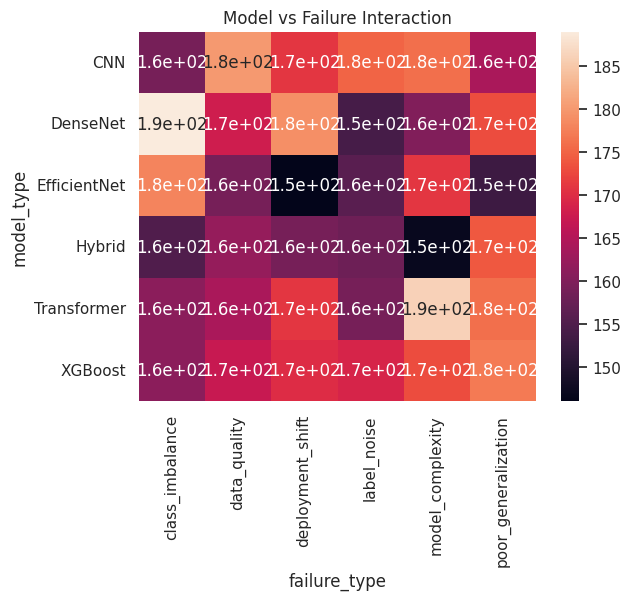

In [ ]:
pivot = df.pivot_table(
    index='model_type',
    columns='failure_type',
    aggfunc='size',
    fill_value=0)

sns.heatmap(pivot, annot=True)
plt.title("Model vs Failure Interaction")
plt.show()

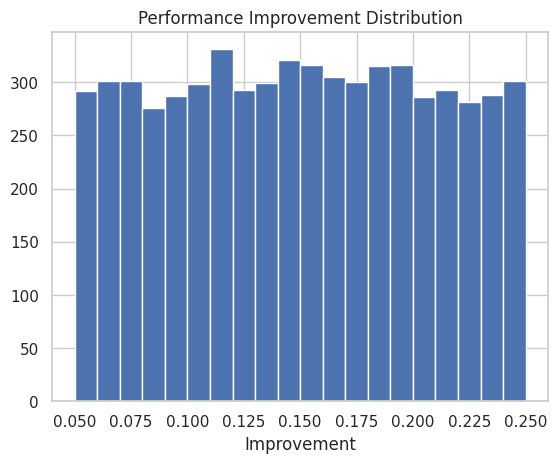

In [ ]:
plt.hist(df['post_fix_f1_score'] - df['f1_score'], bins=20)
plt.title("Performance Improvement Distribution")
plt.xlabel("Improvement")
plt.show()

Most used model:
CNN → 1025


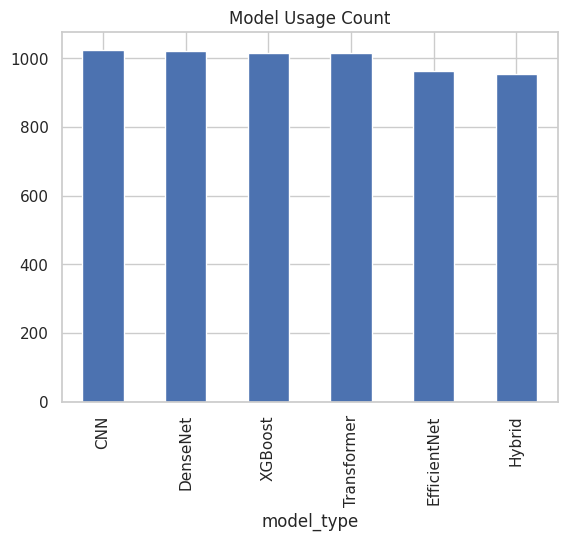

In [ ]:
most_used_model = df['model_type'].value_counts()

print("Most used model:")
print(most_used_model.idxmax(), "→", most_used_model.max())

most_used_model.plot(kind='bar', title="Model Usage Count")
plt.show()

Most frequent failure:
poor_generalization → 1017


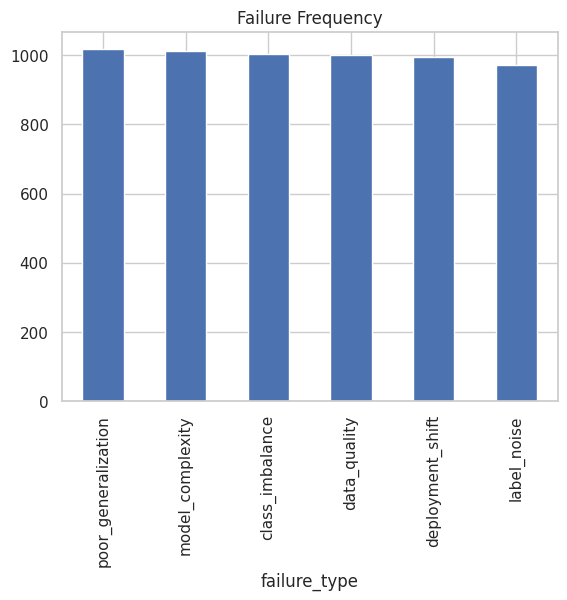

In [ ]:
failure_counts = df['failure_type'].value_counts()

print("Most frequent failure:")
print(failure_counts.idxmax(), "→", failure_counts.max())

failure_counts.plot(kind='bar', title="Failure Frequency")
plt.show()

Domain with most failures:
fraud → 1040


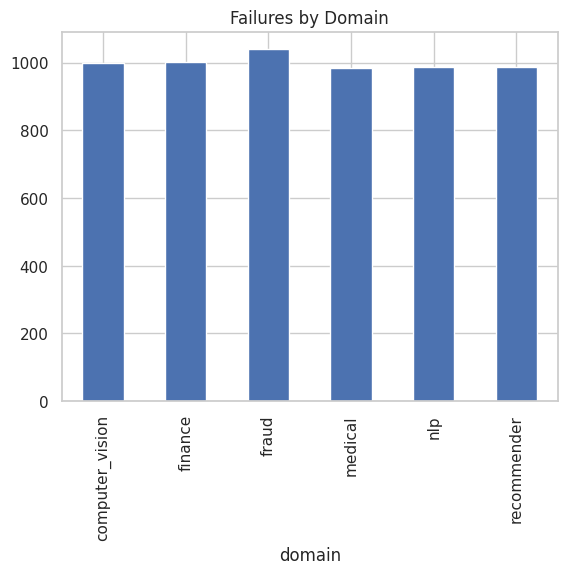

In [ ]:
domain_fail = df.groupby('domain')['failure_type'].count()

print("Domain with most failures:")
print(domain_fail.idxmax(), "→", domain_fail.max())

domain_fail.plot(kind='bar', title="Failures by Domain")
plt.show()

Model that fails most:
CNN → 1025


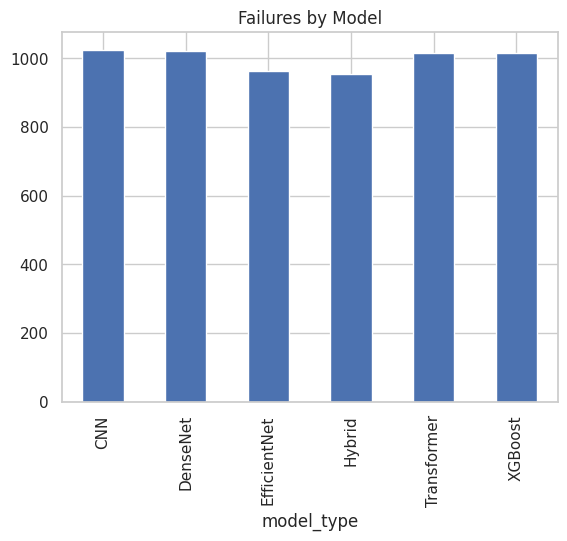

In [ ]:
model_fail = df.groupby('model_type')['failure_type'].count()

print("Model that fails most:")
print(model_fail.idxmax(), "→", model_fail.max())

model_fail.plot(kind='bar', title="Failures by Model")
plt.show()

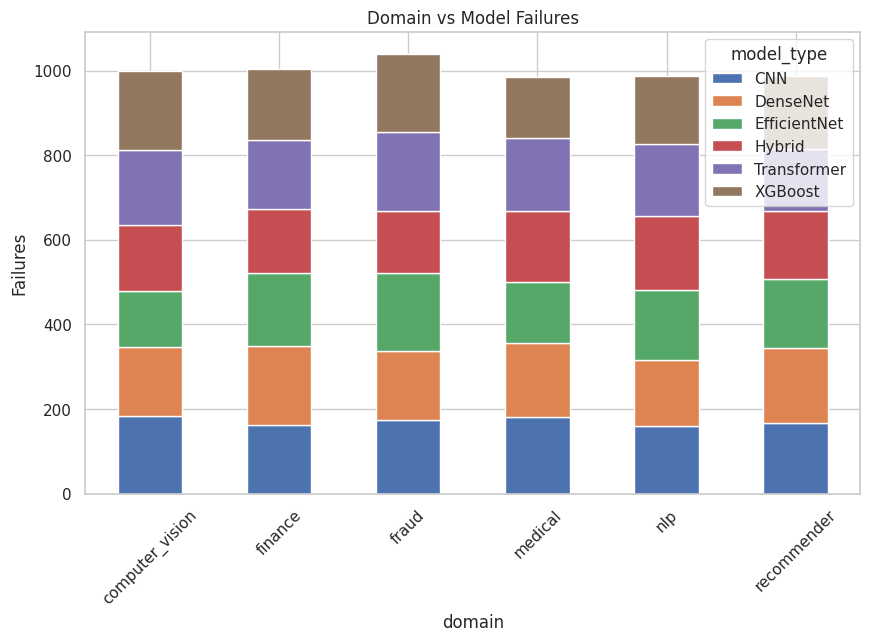

In [ ]:
pivot = df.pivot_table(
    index='domain',
    columns='model_type',
    aggfunc='size',
    fill_value=0)

pivot.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Domain vs Model Failures")
plt.ylabel("Failures")
plt.xticks(rotation=45)
plt.show()

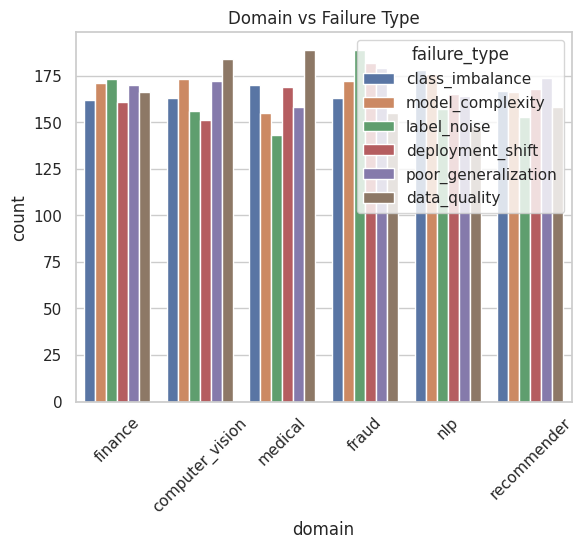

In [ ]:
sns.countplot(data=df, x='domain', hue='failure_type')
plt.xticks(rotation=45)
plt.title("Domain vs Failure Type")
plt.show()

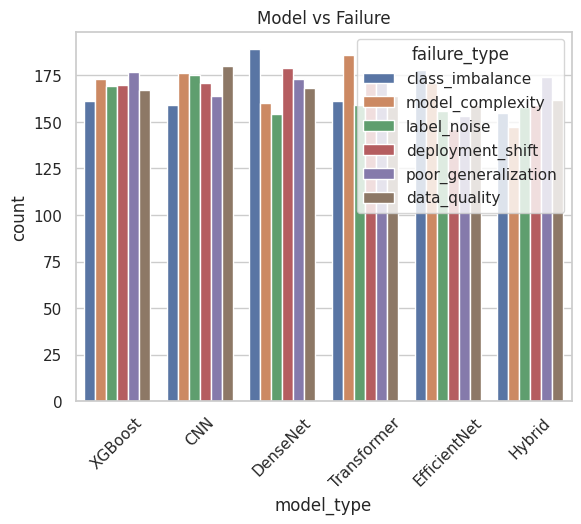

In [ ]:
sns.countplot(data=df, x='model_type', hue='failure_type')
plt.xticks(rotation=45)
plt.title("Model vs Failure")
plt.show()

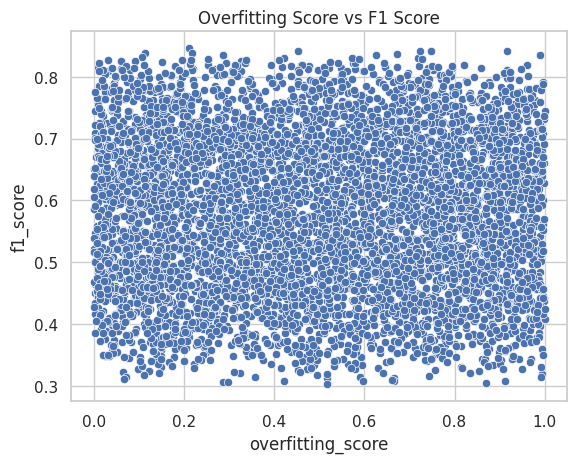

In [ ]:
sns.scatterplot(x=df['overfitting_score'], y=df['f1_score'])
plt.title("Overfitting Score vs F1 Score")
plt.show()

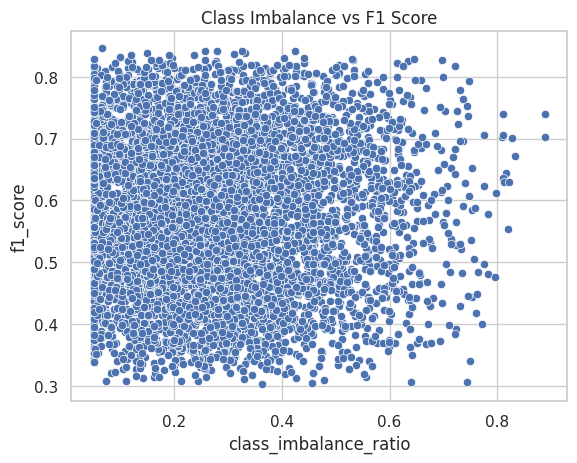

In [ ]:
sns.scatterplot(x=df['class_imbalance_ratio'], y=df['f1_score'])
plt.title("Class Imbalance vs F1 Score")
plt.show()

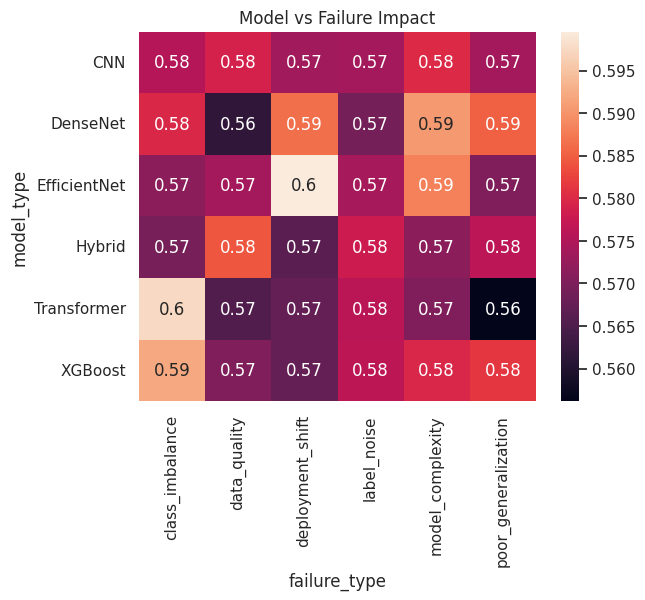

In [ ]:
pivot = pd.pivot_table(
    df,
    values='f1_score',
    index='model_type',
    columns='failure_type'
)

sns.heatmap(pivot, annot=True)
plt.title("Model vs Failure Impact")
plt.show()

In [ ]:
print("Most Common Failure:")
print(df['failure_type'].value_counts().idxmax())

print("\nBest Performing Domain:")
print(df.groupby('domain')['f1_score'].mean().idxmax())

# Calculate improvement before using it
df['improvement'] = df['post_fix_f1_score'] - df['f1_score']

print("\nMost Improved Model:")
print(df.groupby('model_type')['improvement'].mean().idxmax())

Most Common Failure:
poor_generalization

Best Performing Domain:
fraud

Most Improved Model:
Hybrid


Which Model Fails Most?


Model that fails most:
CNN → 1025


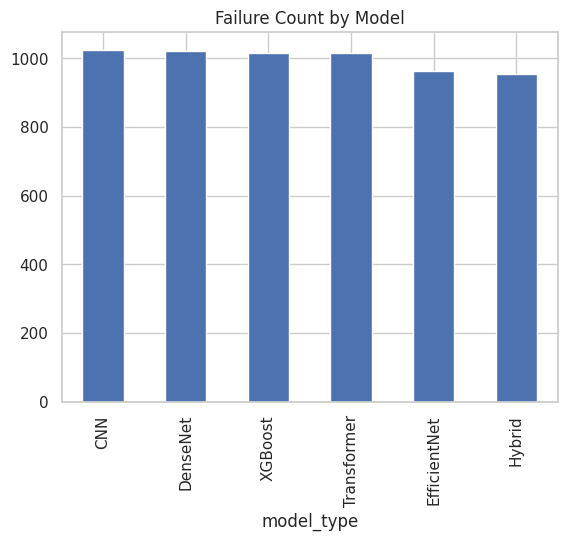

In [ ]:
model_fail = df['model_type'].value_counts()

print("Model that fails most:")
print(model_fail.idxmax(), "→", model_fail.max())

model_fail.plot(kind='bar', title="Failure Count by Model")
plt.show()

Why That Model Fails? (Failure Type Breakdown)

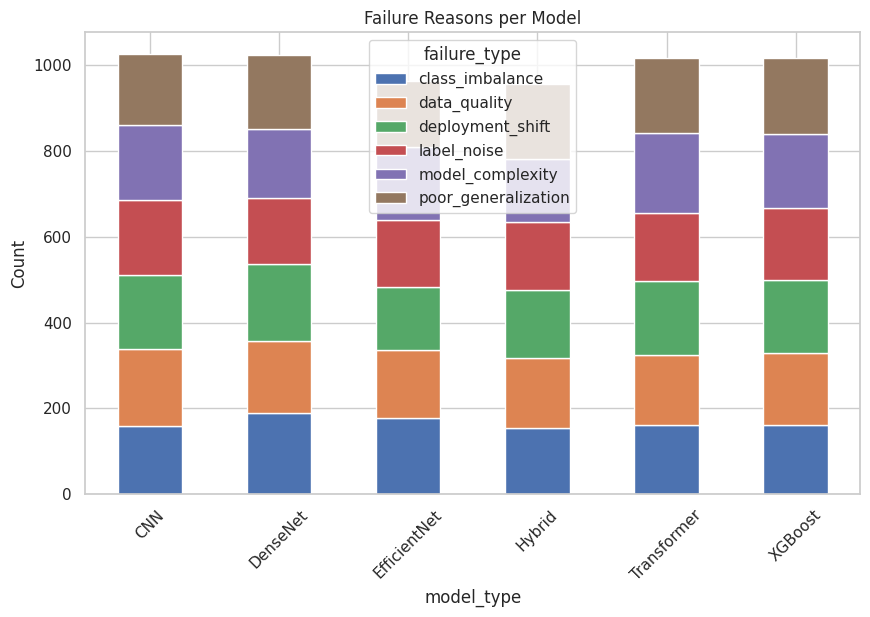

failure_type  class_imbalance  data_quality  deployment_shift  label_noise  \
model_type                                                                   
CNN                       159           180               171          175   
DenseNet                  189           168               179          154   
EfficientNet              178           159               146          156   
Hybrid                    155           162               159          158   
Transformer               161           164               171          159   
XGBoost                   161           167               170          169   

failure_type  model_complexity  poor_generalization  
model_type                                           
CNN                        176                  164  
DenseNet                   160                  173  
EfficientNet               171                  153  
Hybrid                     147                  174  
Transformer                186                  176

In [ ]:
model_failure_reason = df.groupby(['model_type','failure_type']).size().unstack(fill_value=0)

model_failure_reason.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Failure Reasons per Model")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

print(model_failure_reason)

That Model-ku Which Recovery Method Use Pannanga?

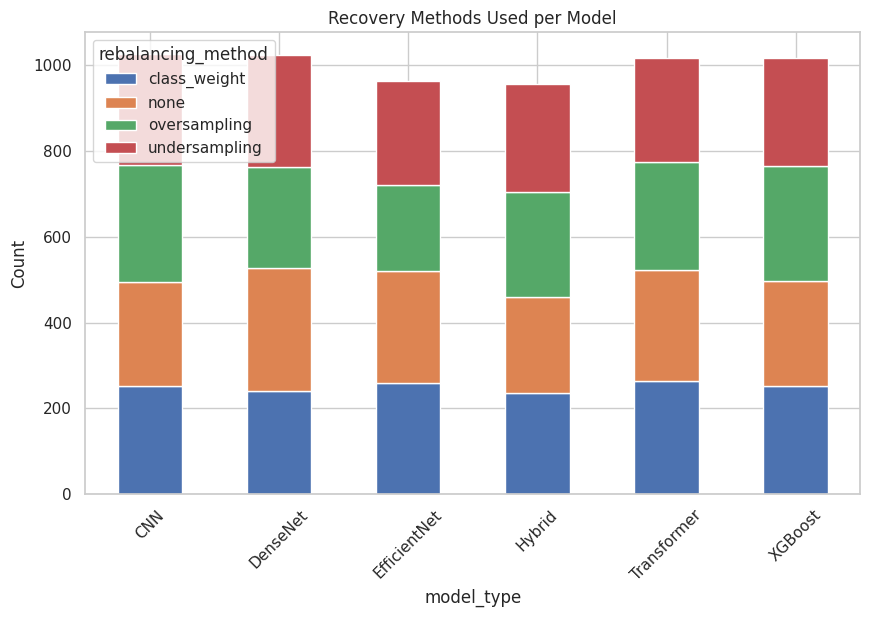

rebalancing_method  class_weight  none  oversampling  undersampling
model_type                                                         
CNN                          252   243           271            259
DenseNet                     241   286           235            261
EfficientNet                 260   259           202            242
Hybrid                       235   225           244            251
Transformer                  263   260           252            242
XGBoost                      252   244           269            252


In [ ]:
model_recovery = df.groupby(['model_type','rebalancing_method']).size().unstack(fill_value=0)

model_recovery.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Recovery Methods Used per Model")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

print(model_recovery)

Overall Most Used Technique?

Most used recovery technique:
none → 1517


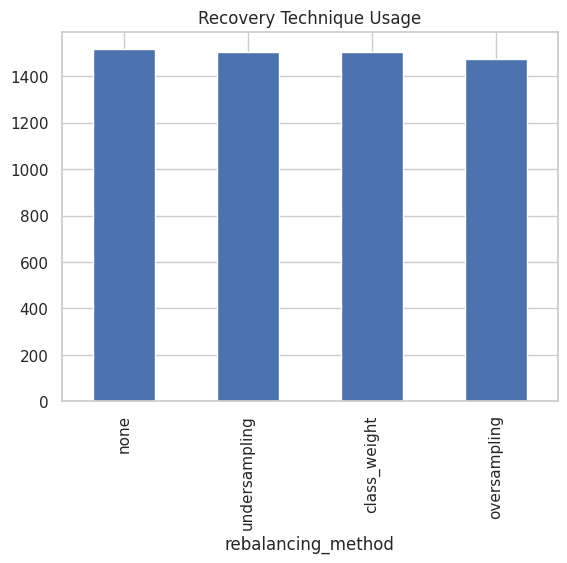

In [ ]:
tech_usage = df['rebalancing_method'].value_counts()

print("Most used recovery technique:")
print(tech_usage.idxmax(), "→", tech_usage.max())

tech_usage.plot(kind='bar', title="Recovery Technique Usage")
plt.show()

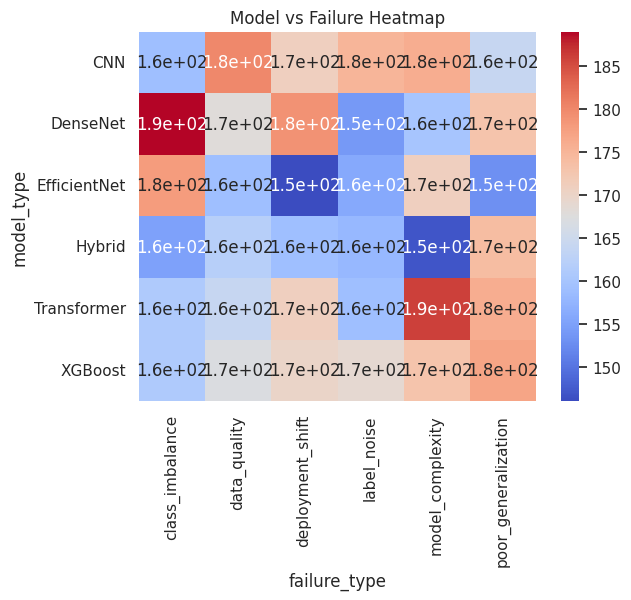

In [ ]:
pivot = df.pivot_table(
    index='model_type',
    columns='failure_type',
    aggfunc='size',
    fill_value=0)

sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title("Model vs Failure Heatmap")
plt.show()